# 06 — Reporting SQL Server

Interrogation directe du star schema `RetraitesOpenData` via SQLAlchemy.
Démontre la pipeline complète : OpenDataSoft API → Parquet → SQL Server → visualisation.

In [1]:
import sys
sys.path.insert(0, '..')
from dotenv import load_dotenv
load_dotenv('../.env')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from src.db import read_sql
from src.visualize import save_fig
%matplotlib inline

print('Connexion SQL Server OK')

Connexion SQL Server OK


## 1. Effectifs retraités — vue `rpt.v_EvolutionEffectifs`

D:\DEV\retraites-opendata\notebooks\..\src\db.py:38: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


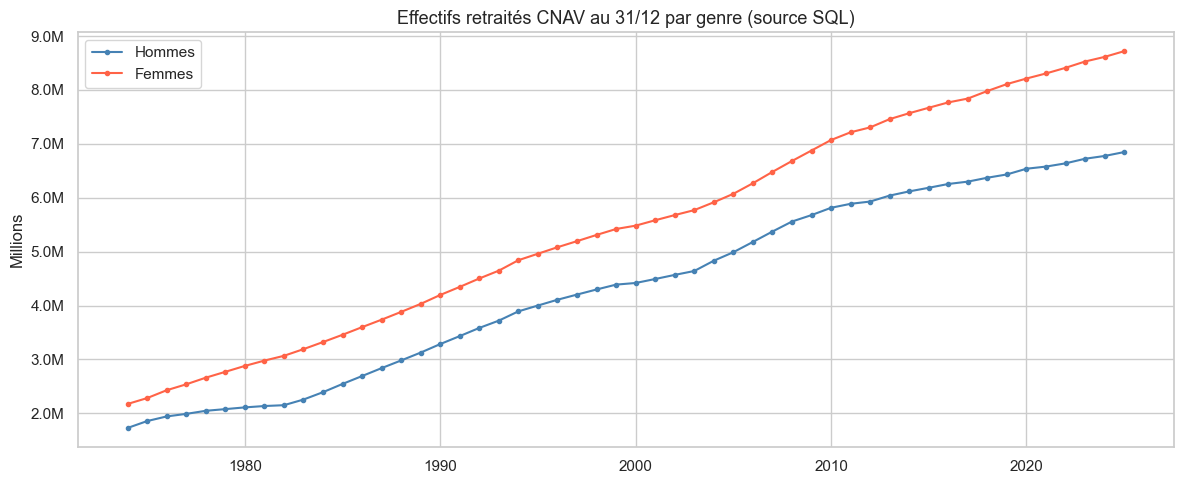

Derniere annee : 2025
 genre  nb_retraites
Femmes       8719858
Hommes       6847592


In [2]:
df_eff = read_sql("""
    SELECT annee, genre, nb_retraites
    FROM rpt.v_EvolutionEffectifs
    ORDER BY annee
""")

pivot = df_eff.pivot(index='annee', columns='genre', values='nb_retraites')

fig, ax = plt.subplots(figsize=(12, 5))
for col, color in [('Hommes', 'steelblue'), ('Femmes', 'tomato')]:
    if col in pivot.columns:
        ax.plot(pivot.index, pivot[col] / 1e6, label=col, color=color, marker='o', markersize=3)

ax.set_title('Effectifs retraités CNAV au 31/12 par genre (source SQL)', fontsize=13)
ax.set_ylabel('Millions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.legend()
plt.tight_layout()
save_fig(fig, 'sql_effectifs_genre')
plt.show()

print(f"Derniere annee : {df_eff['annee'].max()}")
last = df_eff[df_eff['annee'] == df_eff['annee'].max()]
print(last[['genre','nb_retraites']].to_string(index=False))

## 2. Attributions par CARSAT — vue `rpt.v_AttributionsParCARSAT`

D:\DEV\retraites-opendata\notebooks\..\src\db.py:38: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


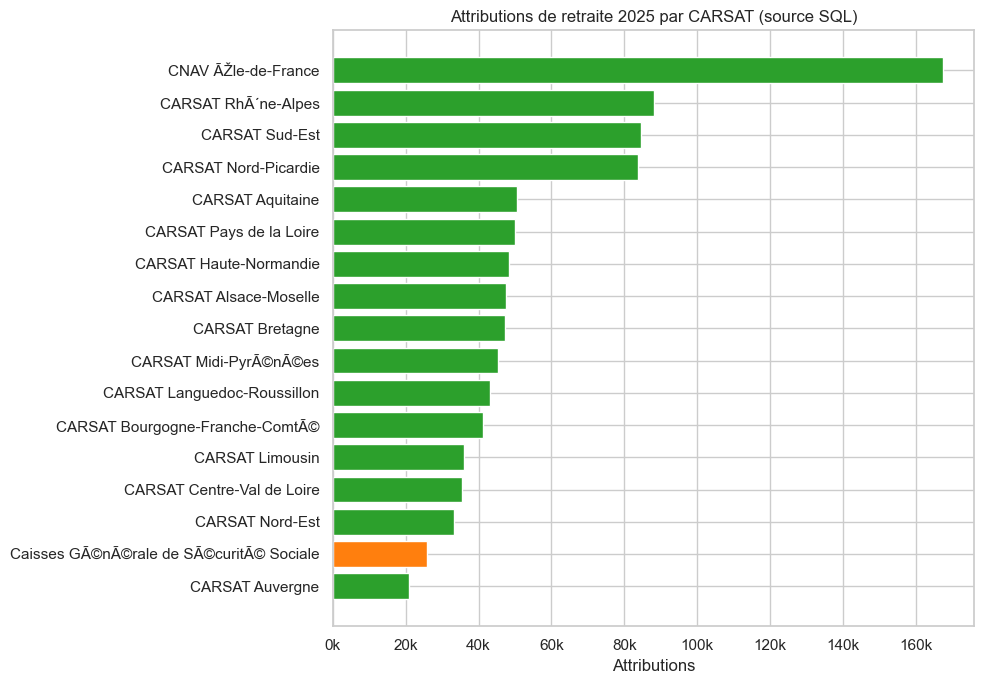

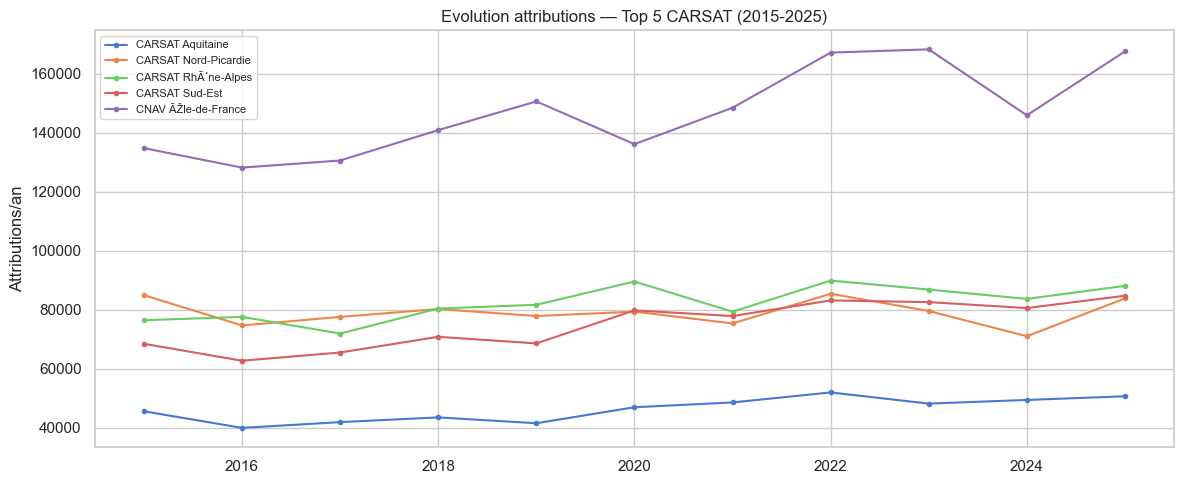

In [3]:
df_attr = read_sql("""
    SELECT carsat, region, annee, nb_attributions
    FROM rpt.v_AttributionsParCARSAT
    ORDER BY annee, nb_attributions DESC
""")

derniere = int(df_attr['annee'].max())
df_last = (df_attr[df_attr['annee'] == derniere]
           .sort_values('nb_attributions', ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ca02c' if r and 'DOM' not in str(r) else '#ff7f0e'
          for r in df_last['region']]
ax.barh(df_last['carsat'], df_last['nb_attributions'], color=colors)
ax.set_xlabel('Attributions')
ax.set_title(f'Attributions de retraite {derniere} par CARSAT (source SQL)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
save_fig(fig, 'sql_attributions_carsat')
plt.show()

# Evolution top 5 sur 10 ans
top5 = df_last.nlargest(5, 'nb_attributions')['carsat'].tolist()
df_top = df_attr[(df_attr['carsat'].isin(top5)) & (df_attr['annee'] >= derniere - 10)]

fig2, ax2 = plt.subplots(figsize=(12, 5))
for carsat, grp in df_top.groupby('carsat'):
    ax2.plot(grp['annee'], grp['nb_attributions'], label=carsat, marker='o', markersize=3)
ax2.set_title(f'Evolution attributions — Top 5 CARSAT ({derniere-10}-{derniere})', fontsize=12)
ax2.set_ylabel('Attributions/an')
ax2.legend(fontsize=8)
plt.tight_layout()
save_fig(fig2, 'sql_top5_carsat_evolution')
plt.show()

## 3. Écart H/F sur les montants — vue `rpt.v_EcartGenreMontants`

In [4]:
col_montant = 'montant_global_mensuel_moyen_attribue_en_euros'
col_annee   = 'annees'

df_gm = pd.read_parquet('../data/processed/montant-global-de-la-retraite-attribuee-selon-le-genre.parquet')
df_gm['annee'] = pd.to_numeric(df_gm[col_annee].astype(str).str.extract(r'(\d{4})')[0], errors='coerce')
df_gm = df_gm.dropna(subset=['annee', col_montant, 'genre']).sort_values('annee')

# Pivot : une colonne par genre
pivot_hf = (df_gm[df_gm['genre'].isin(['Hommes', 'Femmes'])]
            .pivot_table(index='annee', columns='genre', values=col_montant, aggfunc='mean'))

print(pivot_hf.tail(5).to_string())

genre  Femmes  Hommes
annee                
2020    667.0   866.0
2021    668.0   876.0
2022    705.0   919.0
2023    701.0   907.0
2024    747.0   978.0


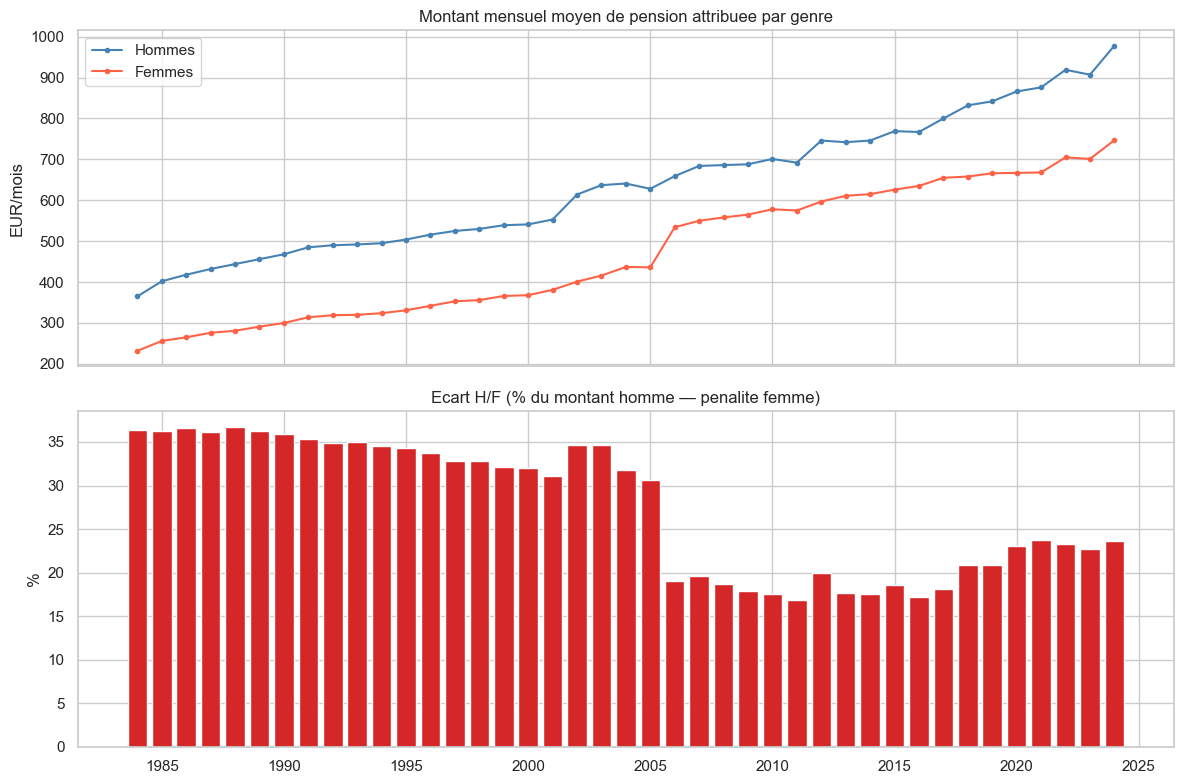

Ecart H/F dernier disponible : 23.6%


In [5]:
pivot_hf['ecart_hf']  = pivot_hf['Hommes'] - pivot_hf['Femmes']
pivot_hf['ecart_pct'] = (pivot_hf['ecart_hf'] / pivot_hf['Hommes'] * 100).round(1)
pivot_hf = pivot_hf.reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(pivot_hf['annee'], pivot_hf['Hommes'], label='Hommes', color='steelblue', marker='o', markersize=3)
axes[0].plot(pivot_hf['annee'], pivot_hf['Femmes'], label='Femmes', color='tomato', marker='o', markersize=3)
axes[0].set_title('Montant mensuel moyen de pension attribuee par genre', fontsize=12)
axes[0].set_ylabel('EUR/mois')
axes[0].legend()

axes[1].bar(pivot_hf['annee'], pivot_hf['ecart_pct'],
            color=['#d62728' if v > 0 else '#2ca02c' for v in pivot_hf['ecart_pct']])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Ecart H/F (% du montant homme — penalite femme)', fontsize=12)
axes[1].set_ylabel('%')

plt.tight_layout()
save_fig(fig, 'sql_ecart_hf_montants')
plt.show()

print(f"Ecart H/F dernier disponible : {pivot_hf['ecart_pct'].iloc[-1]:.1f}%")

## 4. Âge moyen à l'attribution — vue `rpt.v_AgeMoyenAttribution`

D:\DEV\retraites-opendata\notebooks\..\src\db.py:38: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


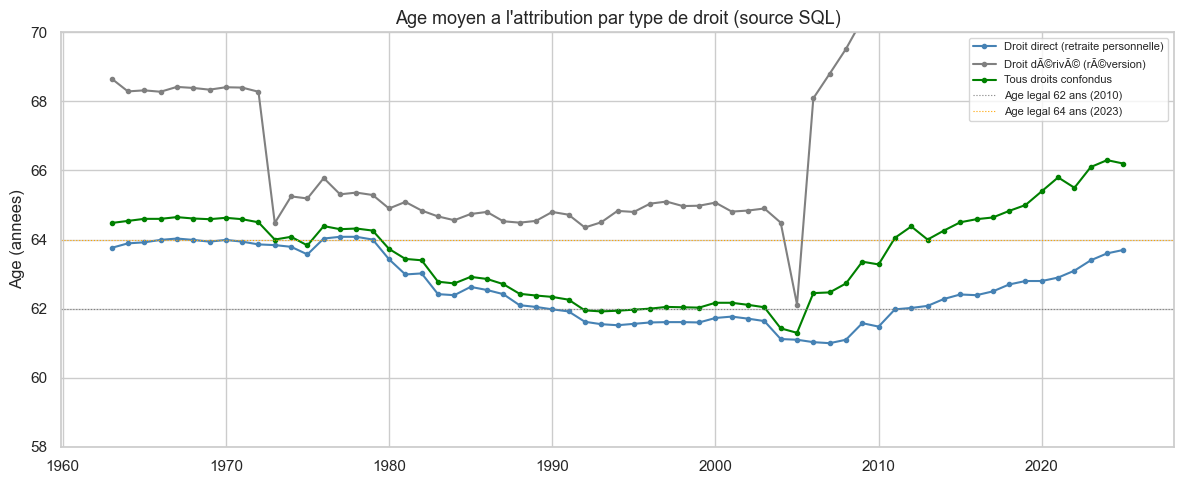


Dernieres valeurs :
                                     annee  age_moyen
type_droit                                           
Droit direct (retraite personnelle)   2025       63.7
Droit dÃ©rivÃ© (rÃ©version)           2025       74.5
Tous droits confondus                 2025       66.2


In [6]:
df_age = read_sql("""
    SELECT annee, type_droit, CAST(age_moyen AS FLOAT) AS age_moyen
    FROM rpt.v_AgeMoyenAttribution
    ORDER BY annee
""")

fig, ax = plt.subplots(figsize=(12, 5))
palette = {'Droit direct (retraite personnelle)': 'steelblue',
           'Droit dérivé (réversion)':            'tomato',
           'Tous droits confondus':               'green'}
for td, grp in df_age.groupby('type_droit'):
    color = palette.get(td, 'gray')
    ax.plot(grp['annee'], grp['age_moyen'], label=td, marker='o', markersize=3, color=color)

ax.axhline(y=62, color='gray', linestyle=':', linewidth=0.8, label='Age legal 62 ans (2010)')
ax.axhline(y=64, color='orange', linestyle=':', linewidth=0.8, label='Age legal 64 ans (2023)')
ax.set_title("Age moyen a l'attribution par type de droit (source SQL)", fontsize=13)
ax.set_ylabel('Age (annees)')
ax.set_ylim(58, 70)
ax.legend(fontsize=8)
plt.tight_layout()
save_fig(fig, 'sql_age_moyen_attribution')
plt.show()

print('\nDernieres valeurs :')
print(df_age.groupby('type_droit').last()[['annee', 'age_moyen']].to_string())

## 5. Durée d'assurance — `fact.DureeAssurance`

D:\DEV\retraites-opendata\notebooks\..\src\db.py:38: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


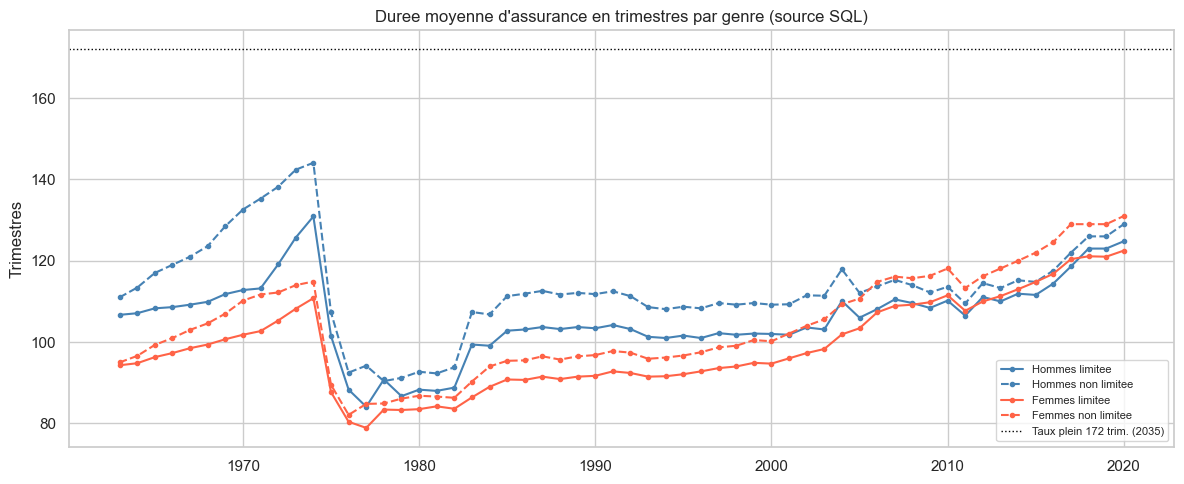

In [7]:
df_dur = read_sql("""
    SELECT a.annee, g.libelle AS genre, d.limitee,
           CAST(d.duree_moyenne_trim AS FLOAT) AS duree_moyenne_trim
    FROM fact.DureeAssurance d
    JOIN dim.Annee a ON a.annee_id = d.annee_id
    JOIN dim.Genre g ON g.genre_id = d.genre_id
    ORDER BY a.annee
""")

fig, ax = plt.subplots(figsize=(12, 5))
styles = {('Hommes', 1): ('steelblue', '-',  'Hommes limitee'),
          ('Hommes', 0): ('steelblue', '--', 'Hommes non limitee'),
          ('Femmes', 1): ('tomato',    '-',  'Femmes limitee'),
          ('Femmes', 0): ('tomato',    '--', 'Femmes non limitee')}

for (genre, lim), (color, ls, label) in styles.items():
    sub = df_dur[(df_dur['genre'] == genre) & (df_dur['limitee'] == lim)]
    ax.plot(sub['annee'], sub['duree_moyenne_trim'], color=color, linestyle=ls,
            label=label, marker='o', markersize=3)

ax.axhline(y=172, color='black', linestyle=':', linewidth=1, label='Taux plein 172 trim. (2035)')
ax.set_title("Duree moyenne d'assurance en trimestres par genre (source SQL)", fontsize=12)
ax.set_ylabel('Trimestres')
ax.legend(fontsize=8)
plt.tight_layout()
save_fig(fig, 'sql_duree_assurance')
plt.show()

## 6. Tableau de bord synthétique — requête croisée SQL

36 annees chargees | derniere : 2025
 annee  total_retraites  pension_moy  age_moyen_attr  part_femmes_pct
  2023       30503878.0        814.0            63.4             55.9
  2024       30778038.0        866.0            63.6             56.0
  2025       31134900.0        891.0            63.7             56.0


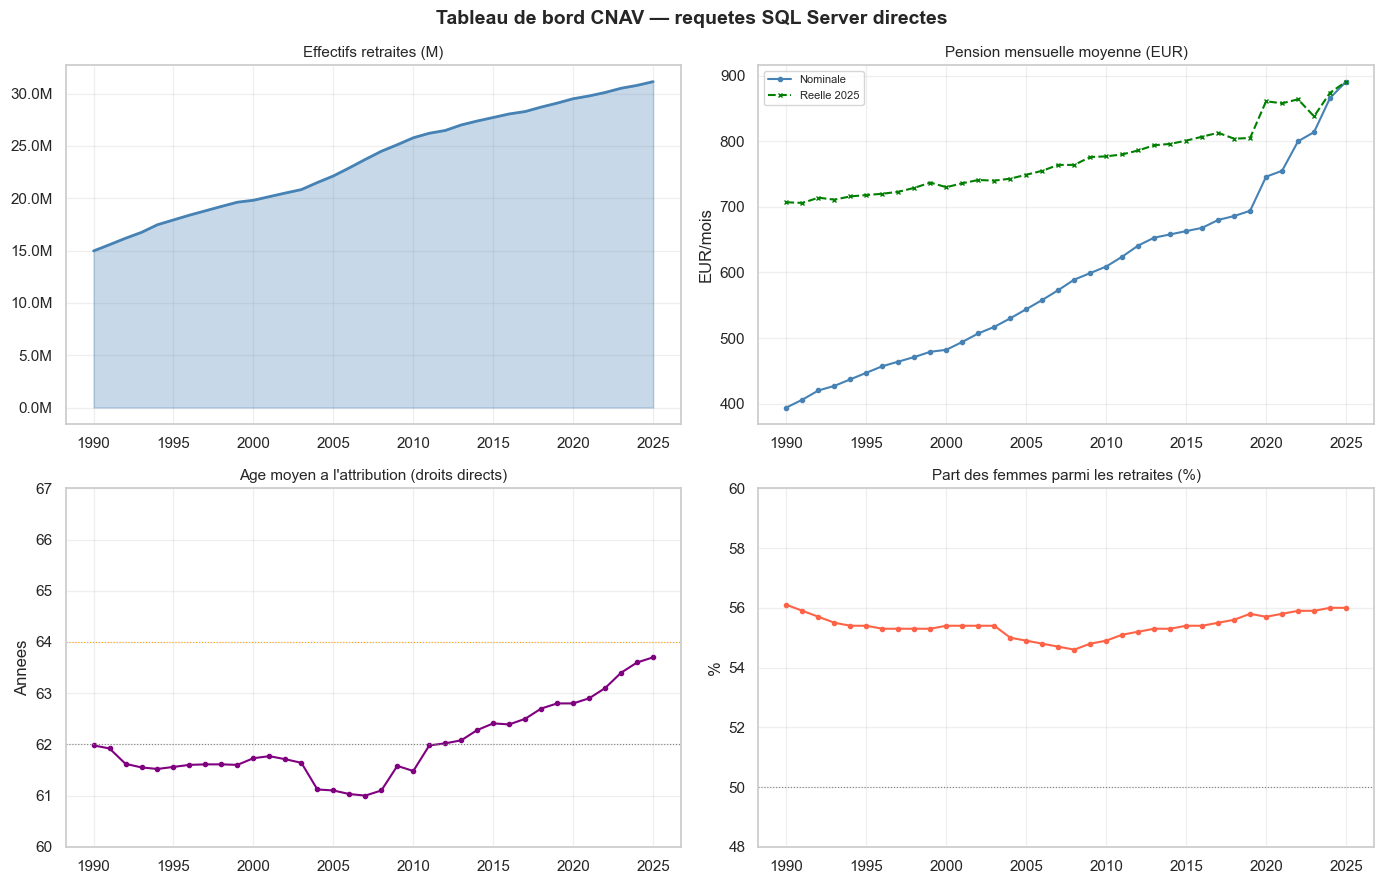

In [8]:
df_bord = read_sql("""
    SELECT
        CAST(a.annee AS INT) AS annee,
        CAST(SUM(e.nb_retraites) AS FLOAT)                                       AS total_retraites,
        CAST(SUM(CASE WHEN g.code = 'H' THEN e.nb_retraites END) AS FLOAT)      AS retraites_h,
        CAST(SUM(CASE WHEN g.code = 'F' THEN e.nb_retraites END) AS FLOAT)      AS retraites_f,
        CAST(MAX(CASE WHEN m.mesure = 'montant_global'          THEN m.montant_euros END) AS FLOAT) AS pension_moy,
        CAST(MAX(CASE WHEN m.mesure = 'montant_global_reel2025' THEN m.montant_euros END) AS FLOAT) AS pension_reel2025,
        CAST(MAX(ag.age_moyen) AS FLOAT) AS age_moyen_attr
    FROM dim.Annee a
    JOIN fact.RetraitesEffectifs e ON e.annee_id = a.annee_id AND e.carsat_id = 99
    JOIN dim.Genre g ON g.genre_id = e.genre_id
    LEFT JOIN fact.Montants m ON m.annee_id = a.annee_id
        AND m.mesure IN ('montant_global', 'montant_global_reel2025')
    LEFT JOIN (
        SELECT annee_id, CAST(MAX(valeur) AS FLOAT) AS age_moyen
        FROM fact.Ages
        WHERE mesure = 'age_moyen_attribution' AND type_droit_id = 1
        GROUP BY annee_id
    ) ag ON ag.annee_id = a.annee_id
    WHERE a.annee BETWEEN 1990 AND 2025
    GROUP BY a.annee
    ORDER BY a.annee
""")

# SQL NULL → None → forcer float64 sur toutes les colonnes
for col in df_bord.columns:
    df_bord[col] = pd.to_numeric(df_bord[col], errors='coerce')

df_bord['part_femmes_pct'] = (df_bord['retraites_f'] / df_bord['total_retraites'] * 100).round(1)

print(f'{len(df_bord)} annees chargees | derniere : {df_bord.annee.max():.0f}')
print(df_bord.tail(3)[['annee','total_retraites','pension_moy','age_moyen_attr','part_femmes_pct']].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Tableau de bord CNAV — requetes SQL Server directes', fontsize=14, fontweight='bold')

axes[0,0].fill_between(df_bord['annee'], df_bord['total_retraites'] / 1e6, alpha=0.3, color='steelblue')
axes[0,0].plot(df_bord['annee'], df_bord['total_retraites'] / 1e6, color='steelblue', linewidth=2)
axes[0,0].set_title('Effectifs retraites (M)', fontsize=11)
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

axes[0,1].plot(df_bord['annee'], df_bord['pension_moy'],
               label='Nominale', color='steelblue', marker='o', markersize=3)
axes[0,1].plot(df_bord['annee'], df_bord['pension_reel2025'],
               label='Reelle 2025', color='green', linestyle='--', marker='x', markersize=3)
axes[0,1].set_title('Pension mensuelle moyenne (EUR)', fontsize=11)
axes[0,1].set_ylabel('EUR/mois')
axes[0,1].legend(fontsize=8)

axes[1,0].plot(df_bord['annee'], df_bord['age_moyen_attr'], color='purple', marker='o', markersize=3)
axes[1,0].axhline(y=62, color='gray', linestyle=':', linewidth=0.8)
axes[1,0].axhline(y=64, color='orange', linestyle=':', linewidth=0.8)
axes[1,0].set_title("Age moyen a l'attribution (droits directs)", fontsize=11)
axes[1,0].set_ylabel('Annees')
axes[1,0].set_ylim(60, 67)

axes[1,1].plot(df_bord['annee'], df_bord['part_femmes_pct'], color='tomato', marker='o', markersize=3)
axes[1,1].axhline(y=50, color='gray', linestyle=':', linewidth=0.8)
axes[1,1].set_title('Part des femmes parmi les retraites (%)', fontsize=11)
axes[1,1].set_ylabel('%')
axes[1,1].set_ylim(48, 60)

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, 'sql_tableau_de_bord')
plt.show()